In [8]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.nca import NeuralCAv1

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

model_path = None

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())   # Should be True
print(torch.cuda.device_count())   # Should show 1
print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1080 Ti"

2.7.1+cu118
11.8
True
1
NVIDIA GeForce GTX 1080 Ti


In [10]:

from ncpu.config import TINY_AND_TRAINING_CONFIG, TINY_AND_CLOSE_TRAINING_CONFIG, TINY_AND_FARAWAY_TRAINING_CONFIG
configs = [
    TINY_AND_TRAINING_CONFIG, 
    TINY_AND_CLOSE_TRAINING_CONFIG, 
    TINY_AND_FARAWAY_TRAINING_CONFIG
]

LEARNING_RATE = 0.01
BATCH_SIZE = 8
GAUSSIAN_NOISE = False
STEPS = 2_500

In [11]:
from ncpu.dataset import NCPUDataset, ScheduledDataset 
datasets = [NCPUDataset(config) for config in configs]
dataset = ScheduledDataset(
    datasets,
    steps = STEPS * BATCH_SIZE,  # this will make shift after N optim_step instead of N/batch_size optim_steps
)


# Learn GATE Logic

In [12]:
from ncpu.trainer import NCPUTrainer

nca = NeuralCAv1(
    channels = 16,
    hidden_channels = 128,
    fire_rate = 0.99,
    alive_masking = 0.5,
    zero_initialization = True,
)

trainer = NCPUTrainer(
    nca,
    dataset.get_dataloader(batch_size=BATCH_SIZE),
    lr=LEARNING_RATE,
    gaussian_noise=GAUSSIAN_NOISE,
)
trainer.sanity_check()

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([8, 32, 32]) -> torch.Size([8, 32, 32])
  first_state: torch.Size([8, 16, 32, 32])
  rollout: torch.Size([8, 11, 16, 32, 32])


AttributeError: 'NCPUTrainer' object has no attribute 'output_mask'

loss=0.029916:  28%|##8       | 700/2500 [04:19<09:59,  3.00it/s]

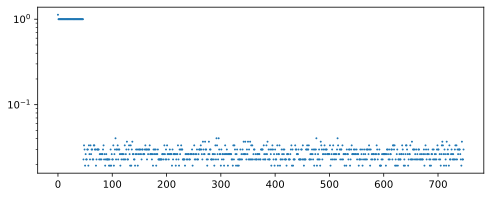

inp    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.07, std=0.26
out    : (8, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.17
nca_out: (8, 32, 32) torch.float32, min=-0.00, max=-0.00, mean=0.00, std=0.00
display size: (64, 64)


,,,,,,,
,,,,,,,
,,,,,,,

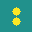
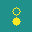
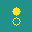
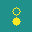
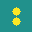
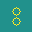
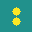
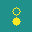
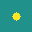
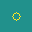
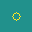
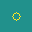
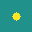
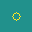
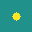
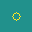
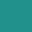
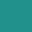
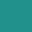
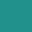
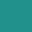
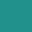
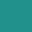
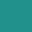

#0,#1,#2,#3,#4,#5,#6,#7

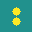
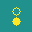
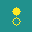
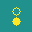
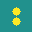
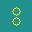
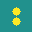
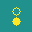

KeyboardInterrupt: 

In [ ]:
stop_loss = 0.0001
pbar = tqdm(range(STEPS))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint("AND_positional.pth", steps=False, timestamp=False)

# Learning Information Propagation

In [9]:
# load seed model
trainer.load_checkpoint("ncpu_AND_positional.pth")

In [ ]:
stop_loss = 0.0001
N_evolutions = 5
STEPS = 2000
if trainer.ds.counter < STEPS * BATCH_SIZE:
    trainer.ds.counter = STEPS * BATCH_SIZE
trainer.ds.steps = STEPS * BATCH_SIZE
pbar = tqdm(range(STEPS * N_evolutions))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

In [ ]:

trainer.save_checkpoint("AND_propagated_5.pth", steps=False, timestamp=False)

In [9]:
# load seed model
trainer.load_checkpoint("ncpu_AND_propagated_5.pth")

In [ ]:
stop_loss = 0.0001
STEPS = 2000
pbar = tqdm(range(STEPS*10))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

    if loss == stop_loss:
        break

trainer.save_checkpoint("AND_checkpoint_final.pth", steps=False, timestamp=False)

In [ ]:
stop_loss = 0.0001
pbar = tqdm(range(1))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"]
    pbar.set_description(f"loss={loss:.6f}")

    clear_output(wait=False)
    display(pbar.container)

    trainer.display_optim_step(info)
